# Damped Harmonic Oscillator PINN — using the gradient tracker

A worked example of applying the two tools (`GradientTracker`, `to_mermaid`) to a
physics-informed neural network. The PINN solves

$$m\,x'' + c\,x' + k\,x = 0,\quad x(0)=x_0,\ x'(0)=v_0$$

with **no training data** — only collocation points and the physics in the loss.
Runs on a laptop CPU in under a minute.

The training loop below is **plain PyTorch I wrote myself**. The tracker does not
own the loop; it observes it through three calls: `accumulate()`, `log_epoch()`,
and the `plot_*` methods. Experiment tracking is done with **MLflow** in local
file mode — runs, metrics, and all artifacts are written to `mlruns/` in this
directory (no server, no extra container). After running, browse them with:

```
mlflow ui --backend-store-uri ./mlruns      # then open http://localhost:5000
```

In [1]:
import sys, os, yaml
sys.path.insert(0, "../..")          # make src/ importable from this example
import numpy as np, torch
import matplotlib.pyplot as plt
%matplotlib inline
import mlflow

from src.gradient_tracker import GradientTracker
from src.architecture import to_mermaid, save_mermaid, save_architecture_png

from oscillator import OscillatorMLP, make_collocation, analytical_solution, physics_loss

cfg = yaml.safe_load(open("config.yaml"))
p = cfg["problem"]
torch.manual_seed(cfg["training"]["seed"]); np.random.seed(cfg["training"]["seed"])

# MLflow writes to a local ./mlruns folder — no server needed.
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("damped_oscillator_pinn")
cfg

{'problem': {'m': 1.0,
  'c': 0.3,
  'k': 4.0,
  'x0': 1.0,
  'v0': 0.0,
  't_max': 20.0,
  'n_collocation': 2000},
 'model': {'hidden_width': 64, 'hidden_depth': 4},
 'training': {'epochs': 300,
  'learning_rate': 0.001,
  'batch_size': 256,
  'w_physics': 1.0,
  'w_ic': 1.0,
  'seed': 42},
 'tracker': {'metric': 'l2_norm'}}

## 1. Build the model and view its architecture

In [2]:
model = OscillatorMLP(cfg["model"]["hidden_width"], cfg["model"]["hidden_depth"])
print(sum(q.numel() for q in model.parameters()), "parameters")
print(to_mermaid(model, input_shape=(1, 1)))

12673 parameters
graph TD
    N0["Input\n[1, 1]"]
    N1["Linear\n1 → 64"]
    N2["Tanh"]
    N3["Linear\n64 → 64"]
    N4["Tanh"]
    N5["Linear\n64 → 64"]
    N6["Tanh"]
    N7["Linear\n64 → 64"]
    N8["Tanh"]
    N9["Linear\n64 → 1"]
    N10["Output"]
    N0 --> N1
    N1 --> N2
    N2 --> N3
    N3 --> N4
    N4 --> N5
    N5 --> N6
    N6 --> N7
    N7 --> N8
    N8 --> N9
    N9 --> N10


Paste the output above into a Markdown cell fenced as ` ```mermaid ` to render it visually.

12673 parameters


2026/06/04 07:47:56 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



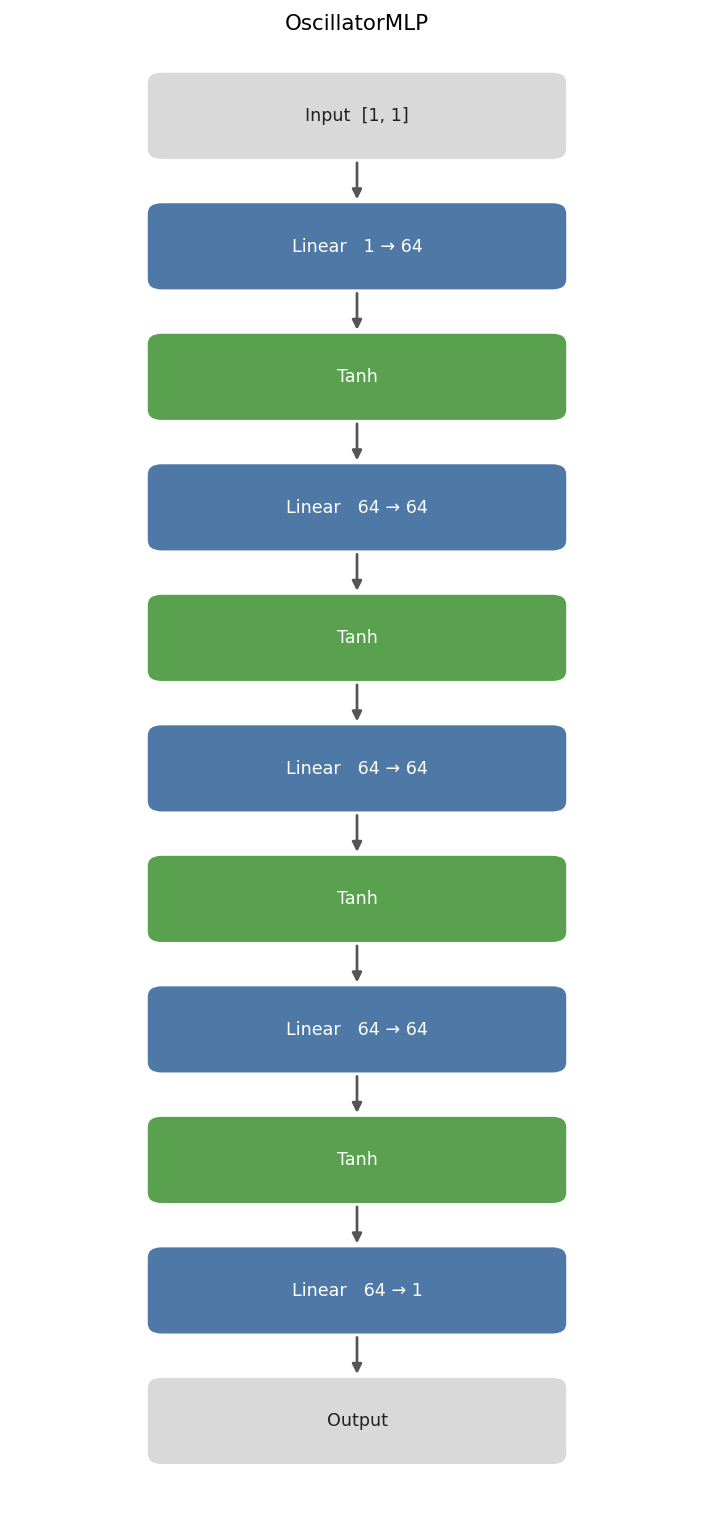

In [3]:
model = OscillatorMLP(cfg["model"]["hidden_width"], cfg["model"]["hidden_depth"])
print(sum(q.numel() for q in model.parameters()), "parameters")

save_architecture_png(model, "architecture.png", input_shape=(1, 1), title="OscillatorMLP")
mlflow.log_artifact("architecture.png")

from IPython.display import Image, display
display(Image("architecture.png"))

## 2. Split collocation points into train / validation

So we get an honest train-vs-val loss curve. The validation points are interior
collocation points the network never sees a gradient step on — the PDE residual
on them measures generalization of the learned solution.

In [4]:
t_all = make_collocation(p["t_max"], p["n_collocation"], seed=cfg["training"]["seed"])
n_val = int(0.15 * t_all.shape[0])
perm0 = torch.randperm(t_all.shape[0], generator=torch.Generator().manual_seed(0))
t_val   = t_all[perm0[:n_val]]
t_train = t_all[perm0[n_val:]]
print(f"{t_train.shape[0]} train pts, {t_val.shape[0]} val pts")

1700 train pts, 300 val pts


## 3. Train — a plain loop with the tracker + MLflow logging wired in

`tracker.accumulate()` after each backward, `tracker.log_epoch(...)` at the end
of each epoch, and `mlflow.log_metric(...)` for the train/val curves. The best
model (lowest val loss) is checkpointed and logged as an artifact.

In [6]:
tracker = GradientTracker(model, metric=cfg["tracker"]["metric"])

opt = torch.optim.Adam(model.parameters(), lr=cfg["training"]["learning_rate"])
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["training"]["epochs"])
bs = cfg["training"]["batch_size"]
w_phys, w_ic = cfg["training"]["w_physics"], cfg["training"]["w_ic"]

history = {"train": [], "val": []}
best_val = float("inf")
best_path = "best_model.pt"

if mlflow.active_run():
    mlflow.end_run()
run = mlflow.start_run(run_name="oscillator_pinn")

# log flattened config as params
for section, params in cfg.items():
    for k, v in params.items():
        mlflow.log_param(f"{section}.{k}", v)

for epoch in range(cfg["training"]["epochs"]):
    # --- train ---
    model.train()
    perm = torch.randperm(t_train.shape[0])
    tot = pde_t = ic_t = 0.0; nb = 0
    for i in range(0, t_train.shape[0], bs):
        batch = t_train[perm[i:i+bs]]
        opt.zero_grad()
        loss, pde, ic = physics_loss(model, batch, p, w_phys, w_ic)
        loss.backward()
        tracker.accumulate()
        opt.step()
        tot += float(loss); pde_t += float(pde); ic_t += float(ic); nb += 1
    sched.step()
    train_loss = tot / nb

    # --- validate (no optimizer step; residual still needs grad, so no no_grad) ---
    model.eval()
    val_loss, _, _ = physics_loss(model, t_val, p, w_phys, w_ic)
    val_loss = float(val_loss)

    history["train"].append(train_loss); history["val"].append(val_loss)

    # tracker: gradient magnitudes + losses for the heatmap overlay
    tracker.log_epoch(epoch, losses={"train": train_loss, "val": val_loss,
                                     "pde": pde_t/nb, "ic": ic_t/nb})
    # mlflow: scalar curves
    mlflow.log_metric("train_loss", train_loss, step=epoch)
    mlflow.log_metric("val_loss", val_loss, step=epoch)
    mlflow.log_metric("lr", sched.get_last_lr()[0], step=epoch)

    # checkpoint best model on val loss
    if val_loss < best_val:
        best_val = val_loss
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "val_loss": val_loss, "config": cfg}, best_path)

    if epoch % 50 == 0:
        print(f"epoch {epoch:4d}  train {train_loss:.3e}  val {val_loss:.3e}")

mlflow.log_metric("best_val_loss", best_val)
mlflow.log_artifact(best_path)            # best model into mlruns
print(f"done — best val loss {best_val:.3e} (saved to {best_path})")

/tmp/ipykernel_43488/406165017.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  tot += float(loss); pde_t += float(pde); ic_t += float(ic); nb += 1


epoch    0  train 1.805e+00  val 1.174e+00
epoch   50  train 1.051e-01  val 1.443e-01
epoch  100  train 6.445e-02  val 7.502e-02
epoch  150  train 5.028e-02  val 6.388e-02
epoch  200  train 4.743e-02  val 6.025e-02
epoch  250  train 4.446e-02  val 5.385e-02
done — best val loss 5.305e-02 (saved to best_model.pt)


## 4. Train vs validation loss

In [7]:
plt.figure(figsize=(8,4))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("loss (log)")
plt.title("Train vs validation loss"); plt.legend(); plt.grid(True, ls=":", alpha=.4)
plt.savefig("loss_curve.png", dpi=130, bbox_inches="tight"); plt.show()
mlflow.log_artifact("loss_curve.png")

/tmp/ipykernel_43488/1291487752.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig("loss_curve.png", dpi=130, bbox_inches="tight"); plt.show()


## 5. Gradient-flow inspection — the payoff

One layer deeper than the loss curve: *where* did the learning signal flow?
Each plot is saved and logged to MLflow as an artifact.

In [8]:
tracker.plot_heatmap("gradient_heatmap.png"); plt.show()
mlflow.log_artifact("gradient_heatmap.png")

/tmp/ipykernel_43488/3005860718.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  tracker.plot_heatmap("gradient_heatmap.png"); plt.show()


In [9]:
tracker.plot_curves("gradient_curves.png"); plt.show()
mlflow.log_artifact("gradient_curves.png")

/tmp/ipykernel_43488/1855927089.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  tracker.plot_curves("gradient_curves.png"); plt.show()


In [10]:
tracker.plot_contributions("layer_contributions.png"); plt.show()
mlflow.log_artifact("layer_contributions.png")

/tmp/ipykernel_43488/3547310139.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  tracker.plot_contributions("layer_contributions.png"); plt.show()


## 6. Architecture diagram (logged as an artifact too)

In [11]:
save_mermaid(model, "architecture.mmd", input_shape=(1, 1))
mlflow.log_artifact("architecture.mmd")
print("logged architecture.mmd")

logged architecture.mmd


## 7. Did it learn the physics? Compare against the analytical solution

In [12]:
model.eval()
t = np.linspace(0, p["t_max"], 500, dtype=np.float32)
with torch.no_grad():
    pred = model(torch.from_numpy(t).unsqueeze(1)).squeeze(1).numpy()
exact = analytical_solution(t, p)
mae = float(np.mean(np.abs(pred-exact)))

plt.figure(figsize=(9,4))
plt.plot(t, exact, "k-", lw=2, label="analytical")
plt.plot(t, pred, "r--", lw=1.6, label="PINN")
plt.legend(); plt.xlabel("t"); plt.ylabel("x(t)"); plt.grid(True, ls=":", alpha=.4)
plt.title(f"PINN vs analytical (MAE={mae:.3e})")
plt.savefig("solution_vs_analytical.png", dpi=130, bbox_inches="tight"); plt.show()

mlflow.log_metric("solution_mae", mae)
mlflow.log_artifact("solution_vs_analytical.png")
mlflow.end_run()                          # close the MLflow run
print("MAE:", mae)

# Tip: if the fit is loose, the IC term is under-weighted. Try training.w_ic: 10
# in config.yaml — and watch the IC-related gradients change in the heatmap.

MAE: 0.14437423646450043


/tmp/ipykernel_43488/3245311275.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig("solution_vs_analytical.png", dpi=130, bbox_inches="tight"); plt.show()
